# Przekształcenia Punktowe, Arytmetyczne i Logiczne na Obrazach

Notatnik prezentuje implementację bazowych, bezkontekstowych operacji na cyfrowych reprezentacjach obrazów. 

Projekt obejmuje:
- Optymalizację transformacji nieliniowych za pomocą tablic LUT (Look-Up Table).
- Wykonywanie dwuargumentowych operacji arytmetycznych (fuzja obrazów, różnice klatek, maskowanie) z uwzględnieniem problemów przepełnienia (overflow) dla typów całkowitych.
- Operacje na maskach binarnych z wykorzystaniem algebry Boole'a.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


## 1. Operacje z wykorzystaniem Look-Up Table (LUT)

Zastosowanie tablic przekodowań pozwala na błyskawiczne, nieliniowe mapowanie wartości pikseli bez konieczności kosztownego obliczeniowo iterowania po całej macierzy. Jest to standardowa praktyka przy aplikowaniu funkcji kwadratowych, logarytmicznych czy wykładniczych.

In [2]:

!wget https://raw.githubusercontent.com/vision-agh/poc_sw/master/02_Point/lut.py
import lut 


--2026-03-18 00:15:08--  https://raw.githubusercontent.com/vision-agh/poc_sw/master/02_Point/lut.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10330 (10K) [text/plain]
Saving to: 'lut.py'

     0K ..........                                            100% 5,95M=0,002s

2026-03-18 00:15:08 (5,95 MB/s) - 'lut.py' saved [10330/10330]



Wizualizacja wybranej funkcji przekodowania (transformacja kwadratowa):

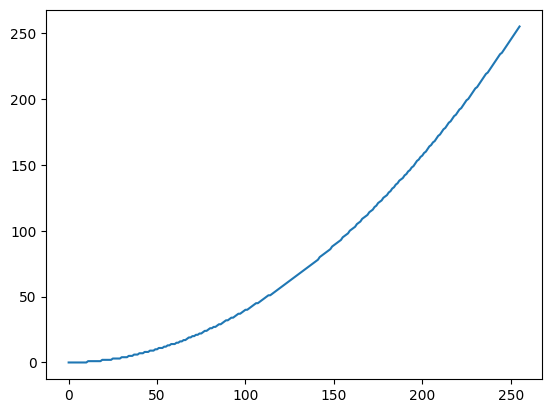

In [3]:
plt.plot(lut.kwadratowa)

Wczytanie obrazu testowego do analizy przekształceń.

--2026-03-18 00:15:08--  https://raw.githubusercontent.com/vision-agh/poc_sw/master/02_Point/lena.bmp
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 66616 (65K) [image/bmp]
Saving to: 'lena.bmp'

     0K .......... .......... .......... .......... .......... 76%  939K 0s
    50K .......... .....                                      100% 99,5M=0,05s

2026-03-18 00:15:09 (1,19 MB/s) - 'lena.bmp' saved [66616/66616]

--2026-03-18 00:15:09--  https://raw.githubusercontent.com/vision-agh/poc_sw/master/02_Point/jet.bmp
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awai

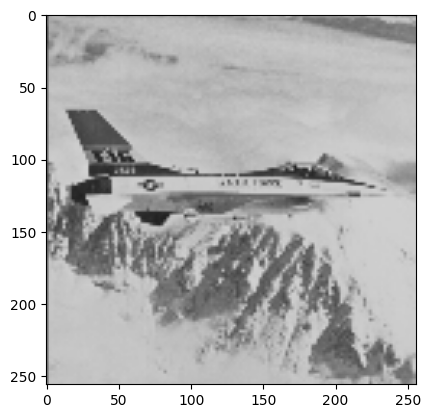

In [4]:
!wget https://raw.githubusercontent.com/vision-agh/poc_sw/master/02_Point/lena.bmp
!wget https://raw.githubusercontent.com/vision-agh/poc_sw/master/02_Point/jet.bmp
JET_IMAGE = cv2.imread('jet.bmp')
plt.imshow(JET_IMAGE)

Aplikacja transformacji odwrotnej (odpowiednik negatywu).

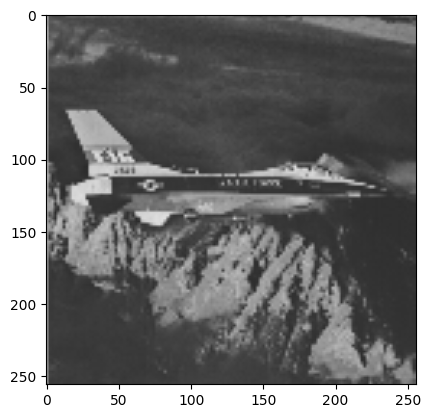

In [5]:
a = cv2.LUT(JET_IMAGE, lut.odwrotna)
plt.imshow(a)
plt.show()

### Automatyzacja wizualizacji przekształceń LUT

Aby ułatwić walidację wpływu różnych funkcji matematycznych na obraz, poniżej zaimplementowano dedykowany moduł wizualizacyjny generujący zestawienie: wykres funkcji, obraz wejściowy oraz wynikowy.

In [6]:
def LUT(image, lut):
    przekodowanie = cv2.LUT(image, lut)
    ax1 = plt.subplot(1, 3, 1)
    ax1.plot(lut)
    ax1.set_title("Wykres przekodowania")
    ax1.set_aspect('equal')
    
    ax2 = plt.subplot(1, 3, 2)
    ax2.imshow(image)
    ax2.set_title("Oryginalny obraz")
    ax2.set_aspect('equal')

    ax3 = plt.subplot(1, 3, 3)
    ax3.imshow(przekodowanie)
    ax3.set_title("Przekształcony obraz")
    ax3.set_aspect('equal')
    plt.show()



Ewaluacja różnych typów przekodowań:

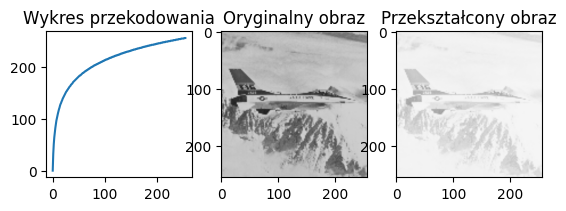

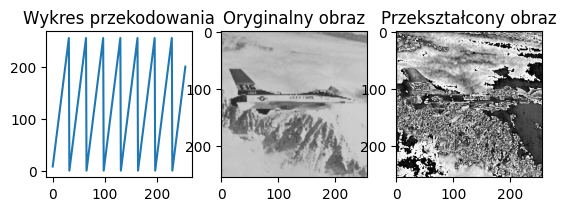

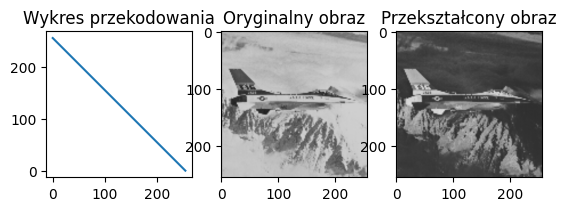

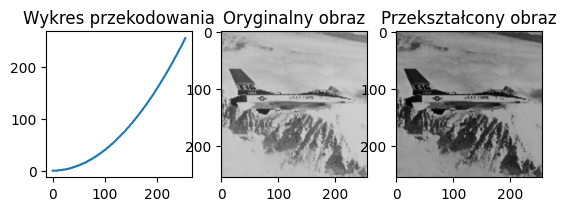

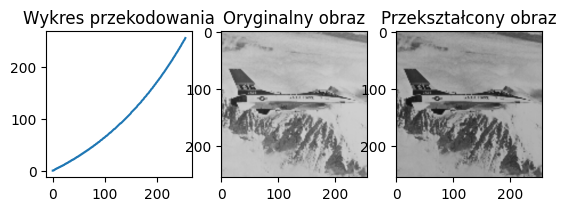

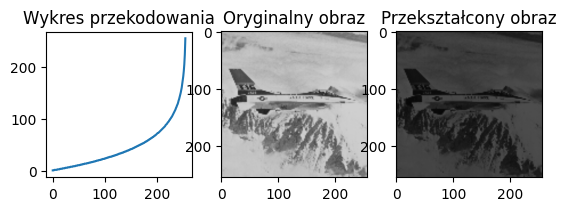

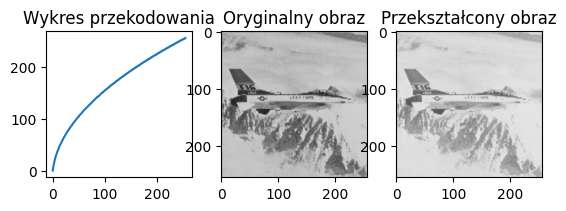

In [7]:
LUT(JET_IMAGE, lut.log)
LUT(JET_IMAGE, lut.pila)
LUT(JET_IMAGE, lut.odwrotna)
LUT(JET_IMAGE, lut.kwadratowa)
LUT(JET_IMAGE, lut.wykladnicza)
LUT(JET_IMAGE, lut.odwlog)
LUT(JET_IMAGE, lut.pierwiastkowa)


## 2. Operacje Arytmetyczne

Dwuargumentowe operacje na macierzach wykorzystywane do detekcji zmian (np. odjęcie tła w monitoringu), nakładania danych (blending) lub selektywnego wygaszania pikseli.

In [8]:
Lena_IMAGE = cv2.imread('lena.bmp')
JET_IMAGE = cv2.imread('jet.bmp')

### Sumowanie obrazów (Zjawisko przepełnienia / Overflow)
Zwykłe dodanie macierzy typu `uint8` niesie ryzyko obcięcia wartości jasności powyżej 255 (zjawisko saturacji lub przewinięcia bitowego w zależności od implementacji).

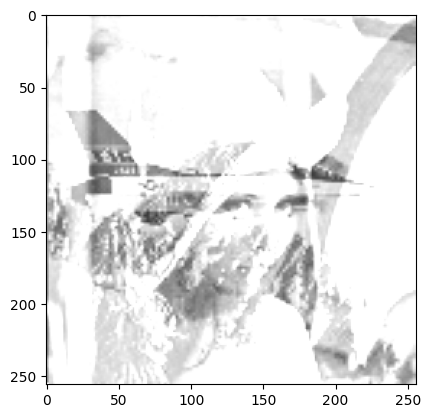

In [9]:
plt.imshow(cv2.add(Lena_IMAGE, JET_IMAGE))
plt.show()

Rozwiązaniem problemu przepełnienia jest rzutowanie (casting) danych do przestrzeni 16-bitowej, bezpieczne wykonanie sumowania, normalizacja do zakresu $[0, 255]$ i powrót do standardu 8-bitowego.

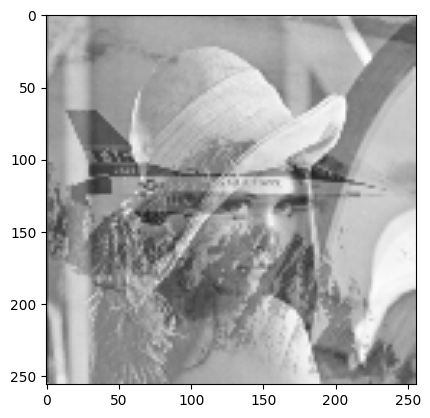

In [10]:
sum16 = JET_IMAGE.astype('uint16') + Lena_IMAGE.astype('uint16')
sum16 = (sum16 / sum16.max())* 255
sum8 = sum16.astype('uint8')
plt.imshow(sum8)

### Kombinacja Liniowa (Alpha Blending)
Metoda wagowego nakładania obrazów, zapobiegająca przekroczeniu zakresu $[0, 255]$ poprzez definicję wag.

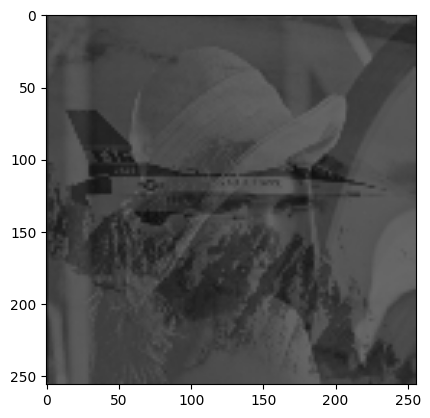

In [11]:
I = cv2.addWeighted(Lena_IMAGE, 0.2, JET_IMAGE, 0.3, 0)
plt.imshow(I)
plt.show()

### Różnica obrazów
Bezpośrednie odjęcie macierzy. Wartości mniejsze od 0 są domyślnie ucinane do 0, co może powodować utratę informacji w ciemnych partiach.

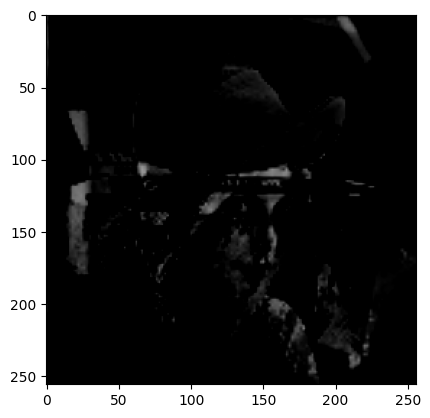

In [12]:
I = cv2.subtract(Lena_IMAGE, JET_IMAGE)
plt.imshow(I)
plt.show()


Optymalnym rozwiązaniem (wykorzystywanym np. przy detekcji ruchu klatka po klatce) jest wyznaczenie modułu z różnicy. Operacja na danych znakowych `int16` pozwala ominąć obcinanie na zerze, gwarantując precyzyjny obraz zmian.

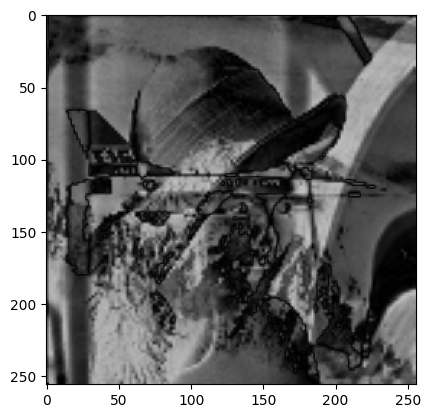

In [13]:
roznica = Lena_IMAGE.astype('int16') - JET_IMAGE.astype('int16')
roznica = np.abs(roznica)
roznica = roznica.astype('uint8')
plt.imshow(roznica)
plt.show()

### Maskowanie (Iloczyn punktowy)
Mnożenie piksel w piksel dwóch standardowych obrazów zazwyczaj generuje obraz bezużyteczny analitycznie. Głównym celem tej operacji jest zastosowanie binarnej maski (Region of Interest - ROI), aby odizolować interesujący fragment sceny.

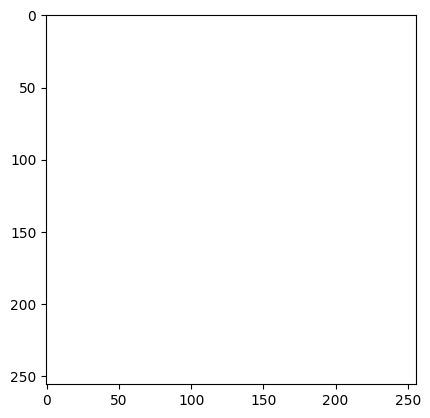

In [14]:
mnozenie = cv2.multiply(Lena_IMAGE, JET_IMAGE)
plt.imshow(mnozenie)
plt.show()

Przekształcenie maski testowej do zakresu binarnego (0 lub 1) i wyizolowanie obszaru kołowego ze zdjęcia.

--2026-03-18 00:15:10--  https://raw.githubusercontent.com/vision-agh/poc_sw/master/02_Point/kolo.bmp
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 66614 (65K) [image/bmp]
Saving to: 'kolo.bmp'

     0K .......... .......... .......... .......... .......... 76%  990K 0s
    50K .......... .....                                      100% 16,3M=0,05s

2026-03-18 00:15:11 (1,24 MB/s) - 'kolo.bmp' saved [66614/66614]



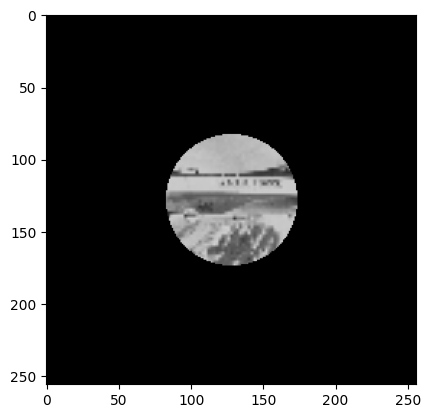

In [15]:
!wget https://raw.githubusercontent.com/vision-agh/poc_sw/master/02_Point/kolo.bmp
maska = cv2.imread('kolo.bmp')
maska= maska.astype('bool').astype('uint8')
wynik = cv2.multiply(maska, JET_IMAGE)
plt.imshow(wynik)    
plt.show()

Odwrócenie logiczne (Negatyw).

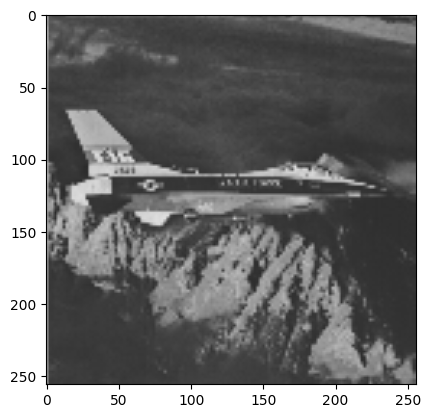

In [16]:
neg = cv2.bitwise_not(JET_IMAGE)
plt.imshow(neg)
plt.show()

## 3. Operacje logiczne i Algebra Boole'a

Przekształcenia bitowe stosowane głównie na maskach binarnych. Są one kluczowe przy komponowaniu skomplikowanych obszarów segmentacji (łączenie masek, wykluczanie części wspólnych).

--2026-03-18 00:15:11--  https://raw.githubusercontent.com/vision-agh/poc_sw/master/02_Point/kwadrat.bmp
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 66614 (65K) [image/bmp]
Saving to: 'kwadrat.bmp'

     0K .......... .......... .......... .......... .......... 76%  944K 0s
    50K .......... .....                                      100%  134M=0,05s

2026-03-18 00:15:11 (1,20 MB/s) - 'kwadrat.bmp' saved [66614/66614]

--2026-03-18 00:15:11--  https://raw.githubusercontent.com/vision-agh/poc_sw/master/02_Point/kolo.bmp
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request 

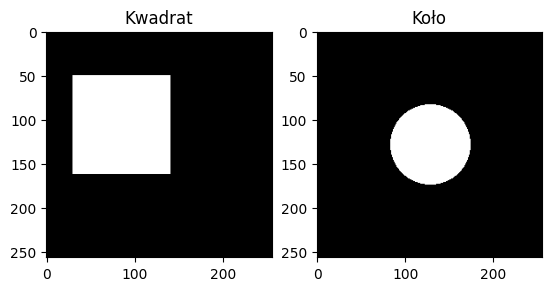

In [17]:
!wget https://raw.githubusercontent.com/vision-agh/poc_sw/master/02_Point/kwadrat.bmp
kwadrat = cv2.imread('kwadrat.bmp')

!wget https://raw.githubusercontent.com/vision-agh/poc_sw/master/02_Point/kolo.bmp
kolo = cv2.imread('kolo.bmp')

plt.subplot(1, 2, 1)
plt.imshow(kwadrat)
plt.title('Kwadrat')

plt.subplot(1, 2, 2)
plt.imshow(kolo)
plt.title('Koło')
plt.show()



Aplikacja podstawowych bramek logicznych (NOT, AND, OR, XOR) realizowana za pomocą wbudowanych mechanizmów bitowych OpenCV.

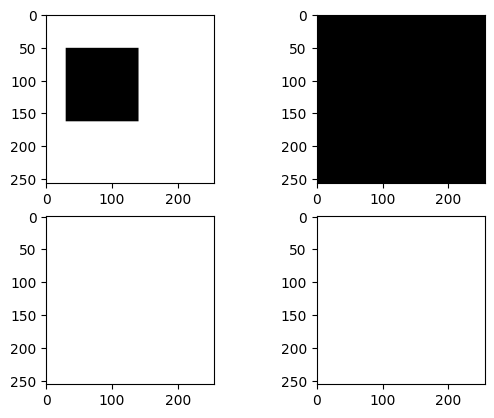

In [18]:
plt.subplot(2, 2, 1)
op1 = cv2.bitwise_not(kwadrat, kolo)
plt.imshow(op1)

plt.subplot(2, 2, 2)
op2 = cv2.bitwise_and(kwadrat, kolo)
plt.imshow(op2)

plt.subplot(2, 2, 3)
op3 = cv2.bitwise_or(kwadrat, kolo)
plt.imshow(op3)

plt.subplot(2, 2, 4)
op4 = cv2.bitwise_xor(kwadrat, kolo)
plt.imshow(op4)

plt.show()